In [1]:
%pip install --upgrade openai

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.3 MB 2.6 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.3 MB 5.3 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 9.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/201.6 kB ? eta -:--:--
   --------------------------------------- 201.6/201.6 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: jiter
    Found existing installation: jiter 0.6.1
    Uninstalling jiter-0.6.1:
      Successfully uninstalled jiter-0.6.1
  Attempting uninstall: openai
    Found existing installation: openai 1.61.1
    Uninstalling openai-1.61.1:
      Successfully uninstalled openai-1.61.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import image_tagger as it
from matplotlib import pyplot as plt

In [3]:
import pydantic

In [4]:
%load_ext autoreload
%autoreload 2

In [7]:
#project_dir = 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger'

input_dir = r"C:\Users\oloon\OneDrive\Desktop\projects\image_tagger\gallery3"
output_dir = r"C:\Users\oloon\OneDrive\Desktop\projects\image_tagger\gallery3"
metadata_filename = os.path.join(output_dir, 'image_metadata.csv')
gallery_filename = os.path.join(output_dir, 'index.html')

In [8]:
# it.scramble_image_directory(input_dir, output_dir)

In [9]:
filepaths = it.find_images(input_dir)
print("number of image files:", len(filepaths))
filepaths

number of image files: 256


['C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\AalEXoIV.png',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\AdiJEGsP.png',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\afkdsvwM.jpeg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\afzieusp.jpg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\AHLnIXFS.jpg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\amCgxQUn.jpg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\AmgSZEXL.jpg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\AOWIzumo.png',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\APzVnKRO.png',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\aSXiTkQf.jpg',
 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger\\gallery3\\awpZgLAT.jpeg',
 'C:\\Users\\oloon\\OneDrive\\

In [10]:
# it.tag_image(filepaths[0])

In [11]:
it.tag_images(filepaths, metadata_filename, verbose=2)

{'description': 'A colorful puppet or clay-animation style scene showing a simple blue creature as the main subject. The character is rounded and egg-shaped with a smooth bright-blue body, short arms, and large flat feet spread outward while sitting on the ground. It has oversized googly eyes placed close together on top of its head, giving it a surprised or curious expression. One arm is slightly raised, making the pose look tentative or mid-gesture. The creature sits in the center of a whimsical cave-like environment filled with organic rounded shapes in purple, pink, and magenta tones. The floor is patterned with irregular colorful patches, adding to the playful handmade look. Near the blue character are two smaller objects or creatures: a small green blob-like figure on the left with tiny eyes, and a white mushroom-shaped or bone-like object on the right. The background is dark in the middle, creating contrast that draws attention to the bright blue central figure.', 'category': 'a

In [23]:
import pandas as pd
metadata_df = pd.read_csv(metadata_filename)
print(metadata_df.shape)
print('n unique original filenames:', len(set(metadata_df['original_filename'])))
print('n unique clean filenames:', len(set(metadata_df['clean_filename'])))

# pd.set_option('display.max_rows', None)
# metadata_df[ metadata_df['clean_filename'].duplicated(keep=False) ].sort_values(['clean_filename'])[['original_filename', 'clean_filename']]

(246, 15)
n unique original filenames: 246
n unique clean filenames: 246


In [13]:
it.autorename(metadata_filename, verbose=1)

In [22]:
it.generate_gallery(metadata_filename, gallery_filename)

Text(0.5, 0, 'Number of Images')

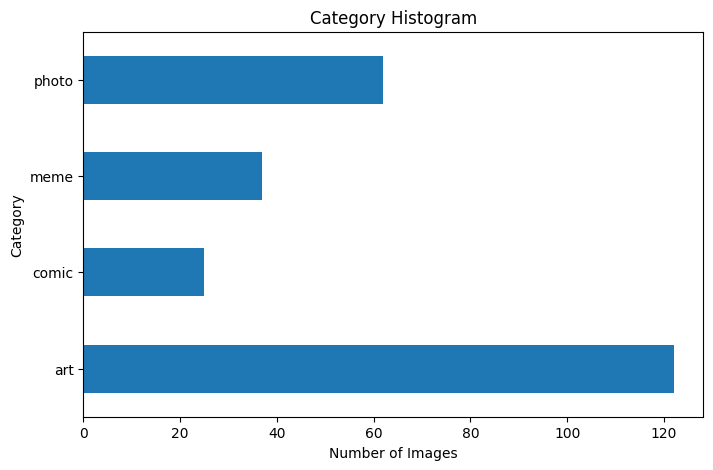

In [24]:
plt.figure(figsize=(8, 5))
metadata_df.groupby('category').size().plot.barh()
plt.title("Category Histogram")
plt.ylabel("Category")
plt.xlabel("Number of Images")

Text(0.5, 0, 'Number of Images')

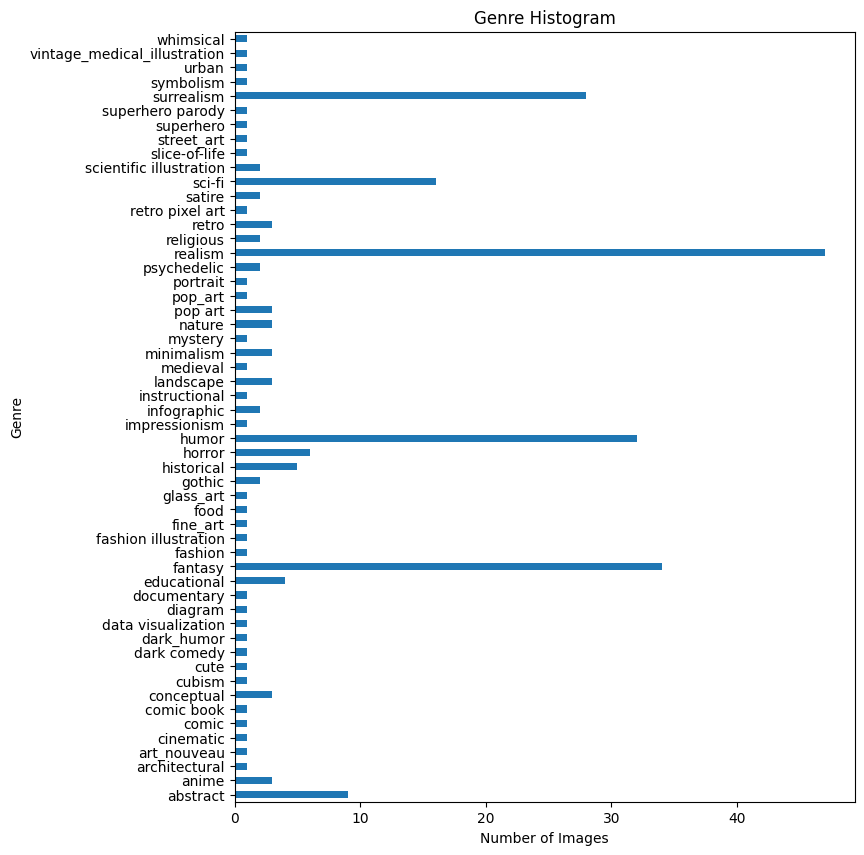

In [27]:
plt.figure(figsize=(8, 10))
metadata_df.groupby('genre').size().plot.barh()
plt.title("Genre Histogram")
plt.ylabel("Genre")
plt.xlabel("Number of Images")

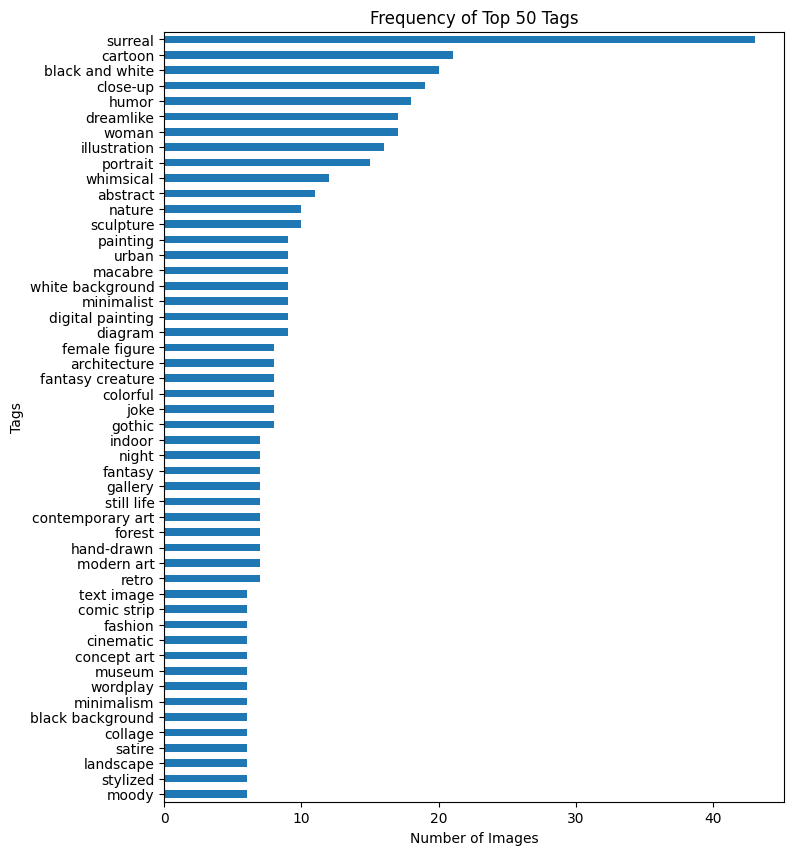

In [34]:
plt.figure(figsize=(8, 10))
tag_counts = metadata_df['tags'].str.split(';').explode('tags').value_counts()
N_TAGS = 50
top_tag_counts = tag_counts[:N_TAGS][::-1]
top_tag_counts.plot.barh()

plt.xlabel('Number of Images')
plt.ylabel('Tags')
plt.title(f'Frequency of Top {N_TAGS} Tags')
plt.show()

quartiles [-9.22337204e+09  5.57987525e+00  6.32892300e+00  7.20055775e+00
  2.14163200e+01]


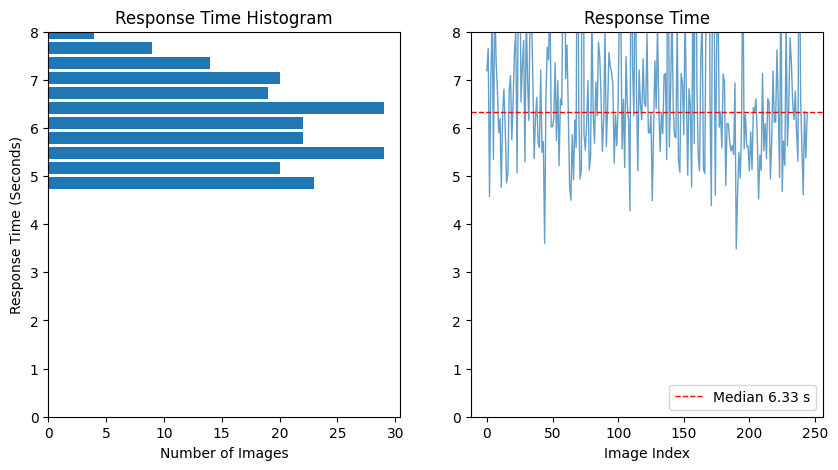

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
delta_seconds = np.array(pd.to_datetime(metadata_df['timestamp']).diff().astype(np.int64)/1e9)

print('quartiles', np.quantile(delta_seconds, [0, 0.25, 0.5, 0.75, 1]))
bounds = np.quantile(delta_seconds, [0.05, 0.95]) # 90% CI
bounded = np.clip(delta_seconds, bounds[0], bounds[1])

plt.subplot(121)
plt.hist(bounded, bins=16, orientation='horizontal', rwidth=0.8)
plt.ylim(0, 8)
plt.ylabel("Response Time (Seconds)")
plt.xlabel("Number of Images")
plt.title("Response Time Histogram")

plt.subplot(122)
plt.plot(delta_seconds[1:], lw=1, alpha=0.7)
plt.ylim(0, 8)
median = np.median(delta_seconds)
plt.axhline(median, linestyle='dashed', label=f'Median {median:0.2f} s', color='red', lw=1)
plt.legend(loc='lower right')
plt.xlabel("Image Index")
plt.title("Response Time");

In [41]:
cost = metadata_df['total_tokens'].sum() * 0.0000025
cost

0.5854775000000001